### Step 0:

Here we provide the relevant parameters values that will allow your sparse autoencoder to get good filters; you do not need to change the parameters below.

In [6]:
import sys
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from __future__ import division
import numpy as np
from numpy.linalg import norm
from numpy.random import rand
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import fmin_l_bfgs_b as minimize
from functools import partial

patchsize = 8                           # We'll use 8x8 patches
numpatches = 10000                      # Number of images to sample 
visibleSize = patchsize*patchsize       # Number of input units 
hiddenSize = 25                         # Number of hidden units 
sparsityParam = 0.01                    # Desired average activation of the hidden units.
                                        # (This was denoted by the Greek alphabet rho, which looks like a lower-case "p" in the lecture notes). 
decayWeight = 0.0001                    # Weight decay parameter       
beta = 3                                # Weight of sparsity penalty term
skip_grad_check = True                 # Used for Step 2 and 3
                                        # Whether to skip a gradient computation check 
                                        # (Quite slow; set to True if you are sure about your implementation)

### Step 1:

### IMPLEMENTATION REQUIRED - Implement 'sampleIMAGES()'

Implement sampleIMAGES.

After implementing sampleIMAGES, the display_network command should display a random sample of 200 patches from the dataset

IMAGES is a 3D array containing 10 images, and Python indexes arrays by starting from 0.


For instance, IMAGES[:,:,0] is a 512x512 array containing the 1st image. Here is a sample image from the dataset.

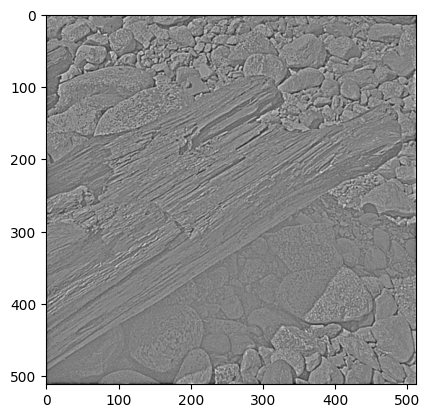

In [8]:
IMAGES = np.load('IMAGES.npy')
from matplotlib import pyplot as plt
plt.imshow(IMAGES[:,:,0])
plt.set_cmap('gray')
plt.show()

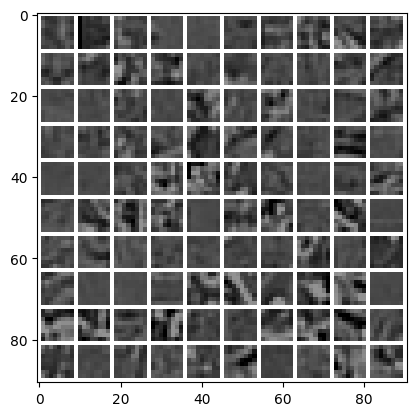

In [9]:
np.random.seed(0)
def sampleIMAGES():
    # sampleIMAGES 
    # Returns 10000 patches for training

    IMAGES = np.load('IMAGES.npy')  # load images from disk

    patches = np.zeros((numpatches, patchsize*patchsize))

    num_images = IMAGES.shape[2]
    max_x = IMAGES.shape[0] - patchsize
    max_y = IMAGES.shape[1] - patchsize

    # Pre-generate all random indices at once (vectorized)
    img_idxs  = np.random.randint(0, num_images,  numpatches)
    x_starts  = np.random.randint(0, max_x + 1,   numpatches)
    y_starts  = np.random.randint(0, max_y + 1,   numpatches)

    for i in range(numpatches):
        patch = IMAGES[x_starts[i]:x_starts[i]+patchsize,
                       y_starts[i]:y_starts[i]+patchsize,
                       img_idxs[i]]
        patches[i] = patch.ravel()

    patches = normalizeData(patches)
    return patches

def normalizeData(patches):
    # Squash data to [0.1, 0.9] since we use sigmoid as the activation
    # function in the output layer
    
    # Remove DC (mean of images). 
    patches = patches-np.mean(patches)
        
    # Truncate to +/-3 standard deviations and scale to -1 to 1
    pstd = 3*np.std(patches)
    patches = np.fmax(np.fmin(patches,pstd),-pstd)/pstd
    
    # Rescale from [-1,1] to [0.1,0.9]
    patches = (patches+1)*0.4+0.1    
    return patches

def displayNetwork(A):
    A = A-A.mean() 
    M, L = A.shape
    sz = int(np.sqrt(L))
    gap = 1

    rows = cols = int(np.sqrt(M))
    while rows*cols < M: 
        rows+=1

    array = np.ones((rows*(sz+gap) + gap, cols*(sz+gap) + gap))

    row_cnt = col_cnt = 0
    for i in range(M):
        x, y = row_cnt*(sz+gap) + gap, col_cnt*(sz+gap) + gap
        array[x : x+sz, y : y+sz] = A[i,:].reshape((sz,sz))
        col_cnt += 1
        if col_cnt >= cols:
            row_cnt += 1
            col_cnt = 0
    plt.imshow(array, cmap='gray')
    plt.show()

patches = sampleIMAGES()
displayNetwork(patches[:100,:])

In [11]:
np.random.seed(0)
#  Obtain random parameters theta
def ravelParameters(W1,W2,b1,b2):
    # Unroll the (W1, W2, b1, b2) matrix/vector format to the theta format.
    return np.concatenate((W1.ravel(),W2.ravel(),b1.ravel(),b2.ravel()))

def initializeParameters(hiddenSize,visibleSize):
    # Initialize parameters randomly based on layer sizes.
    r = np.sqrt(6)/np.sqrt(hiddenSize+visibleSize+1)
    W1 = rand(visibleSize,hiddenSize)*2*r-r
    W2 = rand(hiddenSize,visibleSize)*2*r-r
    b1 = np.zeros((hiddenSize,1))
    b2 = np.zeros((visibleSize,1))

    # Convert weights and bias gradients to the vector form.
    # This step will "unroll" (flatten and concatenate together) all 
    # your parameters into a vector, which can then be used 
    # with scipy.optimize.fmin_l_bfgs_b. 
    theta = ravelParameters(W1,W2,b1,b2)    
    return theta

params = initializeParameters(hiddenSize, visibleSize)

## Step 2: 

### IMPLEMENTATION REQUIRED - Implement 'sparseAutoencoderCost(theta,visibleSize,hiddenSize,decayWeight,sparsityParam,beta,data)'

You can implement all of the components (squared error cost, weight decay term, sparsity penalty) in the cost function at once, but it may be easier to do 
it step-by-step and run gradient checking (see STEP 3) after each step.  We  suggest implementing the sparseAutoencoderCost function using the following steps:

(a) Implement forward propagation in your neural network, and implement the squared error term of the cost function. Implement backpropagation to compute the derivatives.  Then (using decayWeight=beta=0), run Gradient Checking to verify that the calculations corresponding to the squared error cost term are correct.

(b) Add in the weight decay term (in both the cost function and the derivative calculations), then re-run Gradient Checking to verify correctness. 

(c) Add in the sparsity penalty term, then re-run Gradient Checking to verify correctness.

Feel free to change the training settings when debugging your code.  (For example, reducing the training set size or number of hidden units may make your code run faster; and setting beta and/or lambda to zero may be helpful for debugging.)  However, in your final submission of the visualized weights, please use parameters we gave in Step 0 above.

In [12]:
def unravelParameters(theta,hiddenSize,visibleSize):
    # Convert theta to the (W1, W2, b1, b2) matrix/vector format
    W1 = theta[0:hiddenSize*visibleSize].reshape(visibleSize,hiddenSize)
    W2 = theta[hiddenSize*visibleSize:2*hiddenSize*visibleSize].reshape(hiddenSize,visibleSize)
    b1 = theta[2*hiddenSize*visibleSize:2*hiddenSize*visibleSize+hiddenSize]
    b2 = theta[2*hiddenSize*visibleSize+hiddenSize:]
    return W1,W2,b1,b2

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sparseAutoencoderCost(theta,visibleSize,hiddenSize,decayWeight,sparsityParam,beta,data):
    W1,W2,b1,b2 = unravelParameters(theta,hiddenSize,visibleSize)
    m = data.shape[0]

    # ----- Forward pass -----
    # data: (m, visibleSize), W1: (visibleSize, hiddenSize), b1: (hiddenSize,)
    z2 = data @ W1 + b1          # (m, hiddenSize)
    a2 = sigmoid(z2)             # hidden activations
    z3 = a2 @ W2 + b2            # (m, visibleSize)
    a3 = sigmoid(z3)             # output activations

    # ----- Sparsity (KL divergence) -----
    rho = sparsityParam
    rho_hat = a2.mean(axis=0)    # average activation per hidden unit, shape (hiddenSize,)
    kl_div = rho * np.log(rho / rho_hat) + (1 - rho) * np.log((1 - rho) / (1 - rho_hat))

    # ----- Cost -----
    reconstruction  = 0.5 * np.sum((a3 - data) ** 2) / m
    weight_decay    = 0.5 * decayWeight * (np.sum(W1 ** 2) + np.sum(W2 ** 2))
    sparsity_cost   = beta * np.sum(kl_div)
    cost = reconstruction + weight_decay + sparsity_cost

    # ----- Backpropagation -----
    # Output layer error signal (element-wise product with sigmoid derivative)
    d3 = -(data - a3) * a3 * (1 - a3)              # (m, visibleSize)

    # Sparsity gradient contribution at the hidden layer
    sp_grad = beta * (-rho / rho_hat + (1 - rho) / (1 - rho_hat))  # (hiddenSize,)

    # Hidden layer error signal
    d2 = (d3 @ W2.T + sp_grad) * a2 * (1 - a2)     # (m, hiddenSize)

    # Parameter gradients
    W2grad = a2.T @ d3 / m + decayWeight * W2
    W1grad = data.T @ d2 / m + decayWeight * W1
    b2grad = d3.mean(axis=0)
    b1grad = d2.mean(axis=0)

    grad = ravelParameters(W1grad,W2grad,b1grad,b2grad)
    return cost, grad


cost,encoder_grad = sparseAutoencoderCost(params,visibleSize,hiddenSize,
                                      decayWeight,sparsityParam,beta,patches)

## STEP 3: Gradient Checking

### IMPLEMENTATION REQUIRED - Implement 'computeNumericalGradient(J, theta)'

Hint: If you are debugging your code, performing gradient checking on smaller models and smaller training sets (e.g., using only 10 training examples and 1-2 hidden units) may speed things up.
    
First, lets make sure your numerical gradient computation is correct for a simple function.  After you have implemented computeNumericalGradient(), run the following: 

In [13]:
def simpleQuadraticFunction(x):
    value = x[0]**2+3*x[0]*x[1]
    grad = np.zeros(np.shape(x))
    grad[0] = 2*x[0]+3*x[1]
    grad[1] = 3*x[0]
    return value, grad


def computeNumericalGradient(J, theta):
    numgrad = np.zeros(len(theta))
    eps = 1e-4
    # Build all perturbation vectors at once via identity matrix rows
    perturbations = np.eye(len(theta)) * eps
    for i in range(len(theta)):
        fp = J(theta + perturbations[i])
        fm = J(theta - perturbations[i])
        numgrad[i] = ((fp[0] if isinstance(fp, tuple) else fp) -
                      (fm[0] if isinstance(fm, tuple) else fm)) / (2 * eps)
    return numgrad


def checkNumericalGradient():
    x = np.array([4,10])
    value,grad = simpleQuadraticFunction(x)
    numgrad = computeNumericalGradient(simpleQuadraticFunction, x)
    print(np.array([numgrad,grad]).T)
    print("The above two columns you get should be very similar.")
    print("(Left-Your Numerical Gradient, Right-Analytical Gradient)\n\n")
    diff = norm(numgrad-grad)/norm(numgrad+grad)
    print(diff)
    print("Norm of the difference between numerical and analytical gradient (should be < 1e-9)\n\n")

if not skip_grad_check:
    checkNumericalGradient()

    print("Computing numerical gradient of sparseAutoencoderCost...")
    check_cost = partial(sparseAutoencoderCost,visibleSize=visibleSize,
                                            hiddenSize=hiddenSize,
                                            decayWeight=decayWeight,
                                            sparsityParam=sparsityParam,
                                            beta=beta,
                                            data=patches)
    num_grad = computeNumericalGradient(check_cost, params)
    print(np.array([num_grad,encoder_grad]).T)

    diff = norm(num_grad-encoder_grad)/norm(num_grad+encoder_grad)
    print(diff)
    # Should be small. In our implementation, these values are usually less than 1e-9.

## STEP 4:  You can start training your sparse autoencoder

After verifying that your implementation of sparseAutoencoderCost() is correct, you can start training your sparse autoencoder with scipy.optimize.fmin_l_bfgs_b (L-BFGS).

Use L-BFGS to minimize the function. Generally, for scipy.optimize.fmin_l_bfgs_b to work, you need a function with two outputs: the function value and the gradient. In our problem, sparseAutoencoderCost() satisfies this. Here, we set the maximum number of iterations of L-BFGS to run to be 400 (or until convergence).

In [17]:
#Randomly initialize the parameters
theta = initializeParameters(hiddenSize,visibleSize)
opttheta,cost,messages=minimize(sparseAutoencoderCost,theta,fprime=None,maxiter=400,
                                args=(visibleSize,hiddenSize,decayWeight,sparsityParam,beta,patches))

## STEP 5: Visualization save the visualization to a file 

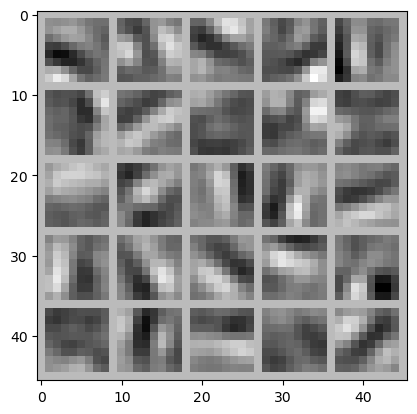

In [14]:
W1,W2,b1,b2 = unravelParameters(opttheta,hiddenSize,visibleSize)
displayNetwork(W1.T) 

## STEP 6: Classes and objects bind the functions together into a SparseAutoencoder class

### IMPLEMENTATION REQUIRED - Implement 'predict(self,sample)' here, just like in 'sparseAutoencoderCost', for forward propagation through the network.

In [15]:
class SparseAutoencoder():
    
    def __init__(self,visibleSize,hiddenSize=25,sparsityParam=0.01,beta=3,decayWeight=0.0001):
        self.visibleSize = visibleSize
        self.hiddenSize = hiddenSize
        self.sparsityParam = sparsityParam
        self.beta = beta
        self.decayWeight = decayWeight
        self.W1 = None
        self.W2 = None
        self.b1 = None
        self.b2 = None
        theta = initializeParameters(self.hiddenSize,self.visibleSize)
        self.W1,self.W2,self.b1,self.b2 = unravelParameters(theta,self.hiddenSize,self.visibleSize)

    def fit(self,patches,maxiter=400):
        theta = ravelParameters(self.W1,self.W2,self.b1,self.b2)
        sparseAutoencoderArgs = (self.visibleSize,self.hiddenSize,self.decayWeight,
                                 self.sparsityParam,self.beta,patches)
        opttheta,cost,messages = minimize(sparseAutoencoderCost,theta,fprime=None,
                                          args=sparseAutoencoderArgs,maxiter=maxiter)
        self.W1,self.W2,self.b1,self.b2 = unravelParameters(opttheta,self.hiddenSize,self.visibleSize)
    
    def predict(self,samples):
        z2 = np.dot(samples,self.W1) + self.b1
        a2 = sigmoid(z2)
        z3 = np.dot(a2,self.W2) + self.b2
        a3 = sigmoid(z3)
        return a3

    def score(self,patches):
        theta = ravelParameters(self.W1,self.W2,self.b1,self.b2)
        return sparseAutoencoderCost(theta,self.visibleSize,self.hiddenSize,self.decayWeight,
                                     self.sparsityParam,self.beta,patches)[0]

In [ ]:
# FULL TRAINING 
sae = SparseAutoencoder(visibleSize=visibleSize,hiddenSize=hiddenSize,sparsityParam=sparsityParam,
                        beta=beta,decayWeight=decayWeight)
print(f'Untrained score: {sae.score(patches)}')
sae.fit(patches,maxiter=2000)
print(f'Trained score: {sae.score(patches)}')

In [19]:
estimates = sae.predict(patches[:100,:])
displayNetwork(sae.W1.T)
displayNetwork(estimates)
displayNetwork(patches[:100,:])
print(f'L1 Error: {np.mean(np.sum(np.abs(estimates-patches[:100,:]),axis=0))}')

NameError: name 'sae' is not defined

In [20]:
import time; t0 = time.time()
print("=== 3A Quick Test ===")
np.random.seed(42)

# Tiny problem: 4-pixel inputs, 2 hidden units, 8 training examples
_vis, _hid, _m = 4, 2, 8
_theta = initializeParameters(_hid, _vis)
_data  = np.random.rand(_m, _vis) * 0.8 + 0.1   # values in [0.1, 0.9]

# 1. Cost returns scalar, gradient has correct shape
_c, _g = sparseAutoencoderCost(_theta, _vis, _hid, 0.0001, 0.01, 3, _data)
assert np.isscalar(_c),             "Cost must be a scalar"
assert _g.shape == _theta.shape,    "Gradient shape mismatch"
print(f"  [1] Cost={_c:.4f}, |grad|={norm(_g):.4f}  ✓")

# 2. Gradient check against numerical gradient
_check = partial(sparseAutoencoderCost, visibleSize=_vis, hiddenSize=_hid,
                 decayWeight=0.0001, sparsityParam=0.01, beta=3, data=_data)
_ng   = computeNumericalGradient(_check, _theta)
_diff = norm(_ng - _g) / norm(_ng + _g)
status = "✓" if _diff < 1e-7 else "⚠ WARNING"
print(f"  [2] Gradient check diff: {_diff:.2e}  (target < 1e-9)  {status}")

# 3. Optimizer reduces cost in 30 iterations
from scipy.optimize import fmin_l_bfgs_b as _opt
_opt_theta, _opt_cost, _ = _opt(sparseAutoencoderCost, _theta, fprime=None, maxiter=30,
                                args=(_vis, _hid, 0.0001, 0.01, 3, _data))
assert _opt_cost < _c, "Cost did not decrease after optimization!"
print(f"  [3] Cost: {_c:.4f} → {_opt_cost:.4f} after 30 iters  ✓")

# 4. SparseAutoencoder class: predict returns correct shape
_sae = SparseAutoencoder(visibleSize=_vis, hiddenSize=_hid)
_sae.W1, _sae.W2, _sae.b1, _sae.b2 = unravelParameters(_opt_theta, _hid, _vis)
_pred = _sae.predict(_data)
assert _pred.shape == _data.shape, "predict() shape mismatch"
assert _pred.min() >= 0 and _pred.max() <= 1, "predict() values outside [0,1]"
print(f"  [4] predict() shape={_pred.shape}, range=[{_pred.min():.3f},{_pred.max():.3f}]  ✓")

print(f"=== PASSED in {time.time()-t0:.1f}s ===")

=== 3A Quick Test ===
  [1] Cost=3.9394, |grad|=2.8023  ✓
  [2] Gradient check diff: 9.00e-11  (target < 1e-9)  ✓
  [3] Cost: 3.9394 → 0.0827 after 30 iters  ✓
  [4] predict() shape=(8, 4), range=[0.352,0.522]  ✓
=== PASSED in 0.0s ===


## Quick Correctness Test (~5 sec)
Run this cell before the full training to verify all implementations are bug-free.